B0 Median + Indicator
AP = 0.1833  ← 4개 중 가장 높음

B1 Median + Indicator + Weight
Recall = 0.0353  ← 4개 중 가장 높음
F1     = 0.0571  ← 4개 중 가장 높음
B0가 Fail을 상대적으로 위쪽에 raning 하는 능력이 가장 나았음.
B1은 기본 판정 기준에서 Fail을 조금 더 적극적으로 잡았음.
그래서 , 우선 rankong능력이 가장 좋았던 B0의 threshold를 움직였을 때 recall을 얼마나 끌어올릴 수 있을 지 확인하겠다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from xgboost import XGBClassifier


# Raw Data
df = pd.read_csv("../01_raw/uci-secom.csv")

sensor_cols = [str(i) for i in range(590)]

X = df[sensor_cols].copy()
y = (df["Pass/Fail"] == 1).astype(int)


# Phase 3과 동일한 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())

(1253, 590) (314, 590)
Pass/Fail
0    1170
1      83
Name: count, dtype: int64


In [2]:
model_b0 = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "xgb",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        )
    )
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [3]:
b0_oof_prob = cross_val_predict(
    model_b0,
    X_train,
    y_train,
    cv=skf,
    method="predict_proba"
)[:, 1]

print("OOF probability count:", len(b0_oof_prob))
print("Min probability:", b0_oof_prob.min())
print("Max probability:", b0_oof_prob.max())

OOF probability count: 1253
Min probability: 2.5759264e-05
Max probability: 0.8097512


In [4]:
threshold_grid = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in threshold_grid:

    y_pred_threshold = (
        b0_oof_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted_Fail": tp + fp,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.round(4)
)

,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
0,0.05,1114,56,67,16,72,0.2222,0.1928,0.2065
1,0.10,1141,29,73,10,39,0.2564,0.1205,0.1639
2,0.15,1150,20,74,9,29,0.3103,0.1084,0.1607
3,0.20,1154,16,76,7,23,0.3043,0.0843,0.1321
4,0.25,1157,13,77,6,19,0.3158,0.0723,0.1176
5,0.30,1161,9,78,5,14,0.3571,0.0602,0.1031
6,0.35,1161,9,78,5,14,0.3571,0.0602,0.1031
7,0.40,1163,7,78,5,12,0.4167,0.0602,0.1053
8,0.45,1166,4,78,5,9,0.5556,0.0602,0.1087
9,0.50,1166,4,81,2,6,0.3333,0.0241,0.0449


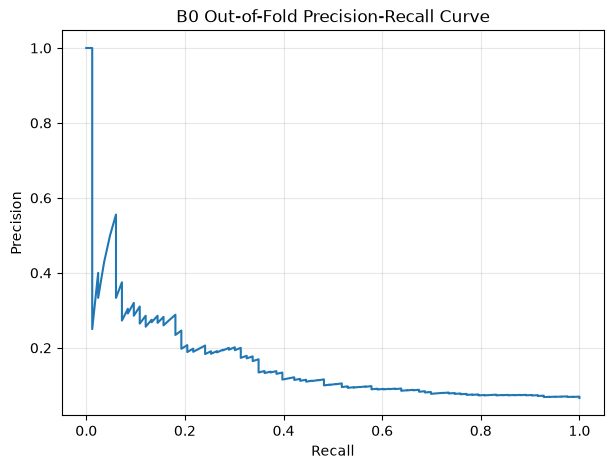

In [5]:
import matplotlib.pyplot as plt

precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_train,
    b0_oof_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("B0 Out-of-Fold Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.show()

phase 5-1의 결론
B0 모델의 OOF 예측 확률을 이용해 decision threshold를 변화시킨 결과, threshold를 낮출수록 Fail Recall은 증가했으나 False Positive 역시 증가하는 trade-off가 확인되었다. 기본 threshold 0.5에서는 83개 Fail 중 2개만 탐지했으나, threshold 0.05에서는 16개를 탐지하였다. 다만 이때 정상 샘플 56개를 Fail로 추가 경고하였다. 따라서 threshold 조정만으로 충분한 불량 탐지 성능을 확보했다고 보기는 어려우며, 공정상 미검출 비용과 추가 검사 비용을 고려한 운영 기준이 필요하다.

In [6]:
b1_oof_prob = np.zeros(len(X_train))

for train_idx, val_idx in skf.split(X_train, y_train):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]

    negative_count = (y_fold_train == 0).sum()
    positive_count = (y_fold_train == 1).sum()

    fold_weight = negative_count / positive_count

    model_b1 = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "xgb",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                scale_pos_weight=fold_weight
            )
        )
    ])

    model_b1.fit(
        X_fold_train,
        y_fold_train
    )

    b1_oof_prob[val_idx] = (
        model_b1.predict_proba(X_fold_val)[:, 1]
    )

print("B1 OOF probability count:", len(b1_oof_prob))

B1 OOF probability count: 1253


In [7]:
b1_threshold_results = []

for threshold in threshold_grid:

    y_pred_threshold = (
        b1_oof_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    b1_threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted_Fail": tp + fp,
        "Precision": precision_score(
            y_train, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_train, y_pred_threshold
        ),
        "F1": f1_score(
            y_train, y_pred_threshold
        )
    })

b1_threshold_df = pd.DataFrame(
    b1_threshold_results
)

display(b1_threshold_df.round(4))

,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
0,0.05,1075,95,64,19,114,0.1667,0.2289,0.1929
1,0.10,1110,60,68,15,75,0.2000,0.1807,0.1899
2,0.15,1128,42,71,12,54,0.2222,0.1446,0.1752
3,0.20,1144,26,71,12,38,0.3158,0.1446,0.1983
4,0.25,1149,21,74,9,30,0.3000,0.1084,0.1593
5,0.30,1155,15,74,9,24,0.3750,0.1084,0.1682
6,0.35,1160,10,76,7,17,0.4118,0.0843,0.1400
7,0.40,1161,9,79,4,13,0.3077,0.0482,0.0833
8,0.45,1162,8,80,3,11,0.2727,0.0361,0.0638
9,0.50,1163,7,80,3,10,0.3000,0.0361,0.0645


In [8]:
%pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import RobustScaler

In [11]:
b2_oof_prob = np.zeros(len(X_train))
b2_fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):

    # -----------------------------
    # Fold Train / Validation 분리
    # -----------------------------
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # -----------------------------
    # 1. Median + Missing Indicator
    #    Train에만 fit
    # -----------------------------
    imputer = SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True
    )

    X_train_imp = imputer.fit_transform(
        X_fold_train
    )

    X_val_imp = imputer.transform(
        X_fold_val
    )

    # 원래 sensor 수 = 590
    n_sensor_features = X_fold_train.shape[1]

    # 뒤쪽에 추가된 컬럼들이 Missing Indicator
    n_total_features = X_train_imp.shape[1]

    indicator_indices = list(
        range(
        n_sensor_features,
        n_total_features
    )
    )

    # -----------------------------
    # 2. SMOTENC 이웃 탐색용 scaling
    #    센서 590개에만 적용
    # -----------------------------
    scaler = RobustScaler()

    X_train_smote_space = X_train_imp.copy()

    X_train_smote_space[:, :n_sensor_features] = (
        scaler.fit_transform(
            X_train_imp[:, :n_sensor_features]
        )
    )

    # -----------------------------
    # 3. Fold Train에만 SMOTENC
    # -----------------------------
    smote_nc = SMOTENC(
        categorical_features=indicator_indices,
        sampling_strategy="auto",
        random_state=42,
        k_neighbors=5
    )

    X_resampled_scaled, y_resampled = (
        smote_nc.fit_resample(
            X_train_smote_space,
            y_fold_train
        )
    )

    # -----------------------------
    # 4. 센서값 scale 원복
    # -----------------------------
    X_resampled = X_resampled_scaled.copy()

    X_resampled[:, :n_sensor_features] = (
        scaler.inverse_transform(
            X_resampled_scaled[:, :n_sensor_features]
        )
    )

    # -----------------------------
    # 5. XGBoost
    #    class weight는 이번엔 사용하지 않음
    # -----------------------------
    model_b2 = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    model_b2.fit(
        X_resampled,
        y_resampled
    )

    # Validation에는 imputation만 적용된 원래 데이터 사용
    y_val_prob = model_b2.predict_proba(
        X_val_imp
    )[:, 1]

    b2_oof_prob[val_idx] = y_val_prob

    y_val_pred = (
        y_val_prob >= 0.5
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_fold_val,
        y_val_pred
    ).ravel()

    b2_fold_results.append({
        "Fold": fold,

        "Train_Pass_Before":
            (y_fold_train == 0).sum(),

        "Train_Fail_Before":
            (y_fold_train == 1).sum(),

        "Train_Pass_After":
            (y_resampled == 0).sum(),

        "Train_Fail_After":
            (y_resampled == 1).sum(),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,

        "Precision": precision_score(
            y_fold_val,
            y_val_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_fold_val,
            y_val_pred
        ),

        "F1": f1_score(
            y_fold_val,
            y_val_pred
        ),

        "AP": average_precision_score(
            y_fold_val,
            y_val_prob
        )
    })

In [12]:
b2_fold_df = pd.DataFrame(
    b2_fold_results
)

display(
    b2_fold_df.round(4)
)

,Fold,Train_Pass_Before,Train_Fail_Before,Train_Pass_After,Train_Fail_After,TN,FP,FN,TP,Precision,Recall,F1,AP
0,1,936,66,936,936,229,5,16,1,0.1667,0.0588,0.0870,0.1807
1,2,936,66,936,936,231,3,15,2,0.4000,0.1176,0.1818,0.2079
2,3,936,66,936,936,233,1,14,3,0.7500,0.1765,0.2857,0.3649
3,4,936,67,936,936,232,2,16,0,0.0000,0.0000,0.0000,0.1425
4,5,936,67,936,936,230,4,14,2,0.3333,0.1250,0.1818,0.2045


In [13]:
b2_oof_pred = (
    b2_oof_prob >= 0.5
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_train,
    b2_oof_pred
).ravel()

b2_ap = average_precision_score(
    y_train,
    b2_oof_prob
)

print("B2 — SMOTENC OOF Results")
print()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print()

print(
    "Precision:",
    round(
        precision_score(
            y_train,
            b2_oof_pred,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_train,
            b2_oof_pred
        ),
        4
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_train,
            b2_oof_pred
        ),
        4
    )
)

print(
    "AP:",
    round(b2_ap, 4)
)

B2 — SMOTENC OOF Results

TN: 1155
FP: 15
FN: 75
TP: 8

Precision: 0.3478
Recall: 0.0964
F1: 0.1509
AP: 0.1769


In [15]:
oof_models = {
    "B0_Median_Indicator": b0_oof_prob,
    "B1_Median_Indicator_Weighted": b1_oof_prob,
    "B2_Median_Indicator_SMOTENC": b2_oof_prob
}

oof_compare_results = []

for model_name, prob in oof_models.items():

    pred = (prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred
    ).ravel()

    oof_compare_results.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Precision": precision_score(
            y_train, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train, pred
        ),
        "F1": f1_score(
            y_train, pred
        ),
        "AP": average_precision_score(
            y_train, prob
        )
    })

oof_comparison_df = pd.DataFrame(
    oof_compare_results
)

display(
    oof_comparison_df.round(4))

,Model,TN,FP,FN,TP,Precision,Recall,F1,AP
0,B0_Median_Indicator,1166,4,81,2,0.3333,0.0241,0.0449,0.1632
1,B1_Median_Indicator_Weighted,1163,7,80,3,0.3000,0.0361,0.0645,0.1561
2,B2_Median_Indicator_SMOTENC,1155,15,75,8,0.3478,0.0964,0.1509,0.1769


In [16]:
b2_threshold_results = []

for threshold in threshold_grid:

    pred = (
        b2_oof_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred
    ).ravel()

    b2_threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted_Fail": tp + fp,
        "Precision": precision_score(
            y_train, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_train, pred
        ),
        "F1": f1_score(
            y_train, pred
        )
    })

b2_threshold_df = pd.DataFrame(
    b2_threshold_results
)

display(
    b2_threshold_df.round(4)
)

,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
0,0.05,1051,119,52,31,150,0.2067,0.3735,0.2661
1,0.10,1096,74,60,23,97,0.2371,0.2771,0.2556
2,0.15,1114,56,63,20,76,0.2632,0.2410,0.2516
3,0.20,1124,46,65,18,64,0.2812,0.2169,0.2449
4,0.25,1132,38,70,13,51,0.2549,0.1566,0.1940
5,0.30,1139,31,70,13,44,0.2955,0.1566,0.2047
6,0.35,1142,28,71,12,40,0.3000,0.1446,0.1951
7,0.40,1146,24,72,11,35,0.3143,0.1325,0.1864
8,0.45,1150,20,74,9,29,0.3103,0.1084,0.1607
9,0.50,1155,15,75,8,23,0.3478,0.0964,0.1509


In [19]:
tuning_folds = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # 1. Median + Missing Indicator
    imputer = SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True
    )

    X_train_imp = imputer.fit_transform(X_fold_train)
    X_val_imp = imputer.transform(X_fold_val)

    n_sensor_features = X_fold_train.shape[1]
    n_total_features = X_train_imp.shape[1]

    indicator_indices = list(
        range(n_sensor_features, n_total_features)
    )

    # 2. SMOTENC 거리 계산용 scaling
    scaler = RobustScaler()

    X_train_smote_space = X_train_imp.copy()

    X_train_smote_space[:, :n_sensor_features] = (
        scaler.fit_transform(
            X_train_imp[:, :n_sensor_features]
        )
    )

    # 3. Fold Train 안에서만 SMOTENC
    smote_nc = SMOTENC(
        categorical_features=indicator_indices,
        sampling_strategy="auto",
        random_state=42,
        k_neighbors=5
    )

    X_resampled_scaled, y_resampled = smote_nc.fit_resample(
        X_train_smote_space,
        y_fold_train
    )

    # 4. Sensor scale 원복
    X_resampled = X_resampled_scaled.copy()

    X_resampled[:, :n_sensor_features] = (
        scaler.inverse_transform(
            X_resampled_scaled[:, :n_sensor_features]
        )
    )

    tuning_folds.append({
        "fold": fold,
        "val_idx": val_idx,
        "X_resampled": X_resampled,
        "y_resampled": np.asarray(y_resampled),
        "X_val": X_val_imp,
        "y_val": y_fold_val.to_numpy()
    })

print("Prepared folds:", len(tuning_folds))

Prepared folds: 5


In [20]:
from sklearn.model_selection import ParameterSampler

In [21]:
param_space = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.02, 0.05, 0.10],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.70, 0.85, 1.00],
    "colsample_bytree": [0.50, 0.70, 0.90, 1.00],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [1.0, 5.0, 10.0]
}

param_candidates = list(
    ParameterSampler(
        param_space,
        n_iter=20,
        random_state=42
    )
)

print("Parameter combinations:", len(param_candidates))

Parameter combinations: 20


In [22]:
tuning_results = []

for i, params in enumerate(param_candidates, start=1):

    oof_prob = np.zeros(len(X_train))

    for fold_data in tuning_folds:

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(
            fold_data["X_resampled"],
            fold_data["y_resampled"]
        )

        val_prob = model.predict_proba(
            fold_data["X_val"]
        )[:, 1]

        oof_prob[
            fold_data["val_idx"]
        ] = val_prob

    # Threshold-independent primary metric
    ap = average_precision_score(
        y_train,
        oof_prob
    )

    # 참고용 기본 threshold = 0.5
    oof_pred = (oof_prob >= 0.5).astype(int)

    precision = precision_score(
        y_train,
        oof_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        oof_pred
    )

    f1 = f1_score(
        y_train,
        oof_pred
    )

    tuning_results.append({
        "Candidate": i,
        "AP": ap,
        "Precision_0.5": precision,
        "Recall_0.5": recall,
        "F1_0.5": f1,
        **params
    })

    print(
        f"{i:02d}/20 | "
        f"AP={ap:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

01/20 | AP=0.1594 | Recall=0.2771 | F1=0.2277
02/20 | AP=0.1688 | Recall=0.1687 | F1=0.2121
03/20 | AP=0.1647 | Recall=0.2048 | F1=0.2152
04/20 | AP=0.1801 | Recall=0.1084 | F1=0.1565
05/20 | AP=0.1643 | Recall=0.1807 | F1=0.2013
06/20 | AP=0.1518 | Recall=0.2289 | F1=0.2289
07/20 | AP=0.1439 | Recall=0.2169 | F1=0.2278
08/20 | AP=0.1777 | Recall=0.0723 | F1=0.1132
09/20 | AP=0.1820 | Recall=0.1084 | F1=0.1579
10/20 | AP=0.1445 | Recall=0.2530 | F1=0.2234
11/20 | AP=0.1648 | Recall=0.2169 | F1=0.2209
12/20 | AP=0.1712 | Recall=0.1446 | F1=0.1752
13/20 | AP=0.1689 | Recall=0.1205 | F1=0.1695
14/20 | AP=0.1502 | Recall=0.2530 | F1=0.2059
15/20 | AP=0.1869 | Recall=0.1687 | F1=0.2276
16/20 | AP=0.1349 | Recall=0.2771 | F1=0.1840
17/20 | AP=0.1686 | Recall=0.1084 | F1=0.1651
18/20 | AP=0.1700 | Recall=0.2048 | F1=0.2313
19/20 | AP=0.1700 | Recall=0.1566 | F1=0.1970
20/20 | AP=0.1661 | Recall=0.1446 | F1=0.1805


In [23]:
tuning_df = pd.DataFrame(tuning_results)

tuning_df = tuning_df.sort_values(
    "AP",
    ascending=False
).reset_index(drop=True)

display(
    tuning_df.head(10).round(4)
)

,Candidate,AP,Precision_0.5,Recall_0.5,F1_0.5,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree
0,15,0.1869,0.3500,0.1687,0.2276,0.70,5.0,0.0,300,5,3,0.05,0.5
1,9,0.1820,0.2903,0.1084,0.1579,1.00,5.0,0.0,300,3,3,0.10,0.9
2,4,0.1801,0.2812,0.1084,0.1565,0.70,5.0,0.0,500,5,5,0.02,0.9
3,8,0.1777,0.2609,0.0723,0.1132,0.85,10.0,0.5,500,1,4,0.10,0.5
4,12,0.1712,0.2222,0.1446,0.1752,0.70,10.0,0.0,100,3,5,0.05,0.7
5,19,0.1700,0.2653,0.1566,0.1970,0.70,1.0,0.5,300,5,2,0.05,1.0
6,18,0.1700,0.2656,0.2048,0.2313,0.70,5.0,0.5,200,10,4,0.02,0.7
7,13,0.1689,0.2857,0.1205,0.1695,1.00,1.0,0.1,300,10,5,0.02,0.5
8,2,0.1688,0.2857,0.1687,0.2121,1.00,5.0,0.5,500,10,3,0.02,0.5
9,17,0.1686,0.3462,0.1084,0.1651,1.00,1.0,0.0,500,5,5,0.10,0.5


In [24]:
best_candidate_id = int(tuning_df.iloc[0]["Candidate"])

best_params = param_candidates[
    best_candidate_id - 1
]

print("Best Candidate:", best_candidate_id)
print("Best AP:", tuning_df.iloc[0]["AP"])

print("\nBest Parameters:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Best Candidate: 15
Best AP: 0.186892617425284

Best Parameters:
subsample: 0.7
reg_lambda: 5.0
reg_alpha: 0.0
n_estimators: 300
min_child_weight: 5
max_depth: 3
learning_rate: 0.05
colsample_bytree: 0.5


In [25]:
sampling_ratios = [0.25, 0.50, 0.75, 1.00]
k_neighbors_list = [3, 5, 7]

smotenc_tuning_results = []

In [26]:
for sampling_ratio in sampling_ratios:

    for k_neighbors in k_neighbors_list:

        oof_prob = np.zeros(len(X_train))

        for fold, (train_idx, val_idx) in enumerate(
            skf.split(X_train, y_train),
            start=1
        ):
            X_fold_train = X_train.iloc[train_idx]
            X_fold_val = X_train.iloc[val_idx]

            y_fold_train = y_train.iloc[train_idx]
            y_fold_val = y_train.iloc[val_idx]

            # ----------------------------------
            # 1. Median + Missing Indicator
            # ----------------------------------
            imputer = SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True
            )

            X_train_imp = imputer.fit_transform(
                X_fold_train
            )

            X_val_imp = imputer.transform(
                X_fold_val
            )

            n_sensor_features = X_fold_train.shape[1]
            n_total_features = X_train_imp.shape[1]

            indicator_indices = list(
                range(
                    n_sensor_features,
                    n_total_features
                )
            )

            # ----------------------------------
            # 2. SMOTENC 이웃 탐색용 scaling
            # ----------------------------------
            scaler = RobustScaler()

            X_train_smote_space = X_train_imp.copy()

            X_train_smote_space[:, :n_sensor_features] = (
                scaler.fit_transform(
                    X_train_imp[:, :n_sensor_features]
                )
            )

            # ----------------------------------
            # 3. Fold Train에만 SMOTENC
            # ----------------------------------
            smote_nc = SMOTENC(
                categorical_features=indicator_indices,
                sampling_strategy=sampling_ratio,
                random_state=42,
                k_neighbors=k_neighbors
            )

            X_resampled_scaled, y_resampled = (
                smote_nc.fit_resample(
                    X_train_smote_space,
                    y_fold_train
                )
            )

            # ----------------------------------
            # 4. Sensor scale 원복
            # ----------------------------------
            X_resampled = X_resampled_scaled.copy()

            X_resampled[:, :n_sensor_features] = (
                scaler.inverse_transform(
                    X_resampled_scaled[
                        :, :n_sensor_features
                    ]
                )
            )

            # ----------------------------------
            # 5. Candidate 15 XGBoost
            # ----------------------------------
            model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,

                subsample=0.7,
                reg_lambda=5.0,
                reg_alpha=0.0,
                n_estimators=300,
                min_child_weight=5,
                max_depth=3,
                learning_rate=0.05,
                colsample_bytree=0.5
            )

            model.fit(
                X_resampled,
                y_resampled
            )

            val_prob = model.predict_proba(
                X_val_imp
            )[:, 1]

            oof_prob[val_idx] = val_prob

        # ----------------------------------
        # 모든 OOF prediction 통합 평가
        # ----------------------------------
        ap = average_precision_score(
            y_train,
            oof_prob
        )

        pred_05 = (
            oof_prob >= 0.5
        ).astype(int)

        precision = precision_score(
            y_train,
            pred_05,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            pred_05
        )

        f1 = f1_score(
            y_train,
            pred_05
        )

        smotenc_tuning_results.append({
            "Sampling_Ratio": sampling_ratio,
            "K_Neighbors": k_neighbors,
            "AP": ap,
            "Precision_0.5": precision,
            "Recall_0.5": recall,
            "F1_0.5": f1
        })

        print(
            f"ratio={sampling_ratio:.2f}, "
            f"k={k_neighbors} | "
            f"AP={ap:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f}"
        )

ratio=0.25, k=3 | AP=0.1723 | Recall=0.0361 | F1=0.0625
ratio=0.25, k=5 | AP=0.1675 | Recall=0.0482 | F1=0.0800
ratio=0.25, k=7 | AP=0.1666 | Recall=0.0361 | F1=0.0632
ratio=0.50, k=3 | AP=0.1932 | Recall=0.0964 | F1=0.1524
ratio=0.50, k=5 | AP=0.1894 | Recall=0.0964 | F1=0.1524
ratio=0.50, k=7 | AP=0.1791 | Recall=0.0723 | F1=0.1143
ratio=0.75, k=3 | AP=0.1907 | Recall=0.1205 | F1=0.1770
ratio=0.75, k=5 | AP=0.1661 | Recall=0.0964 | F1=0.1391
ratio=0.75, k=7 | AP=0.1807 | Recall=0.1084 | F1=0.1607
ratio=1.00, k=3 | AP=0.1987 | Recall=0.1807 | F1=0.2500
ratio=1.00, k=5 | AP=0.1869 | Recall=0.1687 | F1=0.2276
ratio=1.00, k=7 | AP=0.1805 | Recall=0.1325 | F1=0.1849


In [28]:
smotenc_tuning_df = pd.DataFrame(
    smotenc_tuning_results
)

smotenc_tuning_df = (
    smotenc_tuning_df
    .sort_values(
        "AP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    smotenc_tuning_df.round(4)
)

,Sampling_Ratio,K_Neighbors,AP,Precision_0.5,Recall_0.5,F1_0.5
0,1.00,3,0.1987,0.4054,0.1807,0.2500
1,0.50,3,0.1932,0.3636,0.0964,0.1524
2,0.75,3,0.1907,0.3333,0.1205,0.1770
3,0.50,5,0.1894,0.3636,0.0964,0.1524
4,1.00,5,0.1869,0.3500,0.1687,0.2276
5,0.75,7,0.1807,0.3103,0.1084,0.1607
6,1.00,7,0.1805,0.3056,0.1325,0.1849
7,0.50,7,0.1791,0.2727,0.0723,0.1143
8,0.25,3,0.1723,0.2308,0.0361,0.0625
9,0.25,5,0.1675,0.2353,0.0482,0.0800


Current best strategy

Median Imputation
+ Missing Indicator
+ RobustScaler for SMOTENC neighbor search
+ SMOTENC
  - sampling_ratio = 1.0
  - k_neighbors = 3
+ XGBoost
  - n_estimators = 300
  - learning_rate = 0.05
  - max_depth = 3
  - min_child_weight = 5
  - subsample = 0.7
  - colsample_bytree = 0.5
  - reg_lambda = 5.0
  - reg_alpha = 0.0

OOF AP = 0.1987
Precision@0.5 = 0.4054
Recall@0.5 = 0.1807
F1@0.5 = 0.2500

In [29]:
from scipy.stats import f_oneway
from imblearn.over_sampling import SMOTE
import warnings

In [30]:
def get_anova_ranking(X_fold_train, y_fold_train):

    feature_scores = []

    for col in X_fold_train.columns:

        pass_values = (
            X_fold_train.loc[y_fold_train == 0, col]
            .dropna()
            .to_numpy()
        )

        fail_values = (
            X_fold_train.loc[y_fold_train == 1, col]
            .dropna()
            .to_numpy()
        )

        # 데이터가 너무 적으면 ranking에 사용하지 않음
        if len(pass_values) < 2 or len(fail_values) < 2:
            f_stat = 0.0

        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                f_stat, _ = f_oneway(
                    pass_values,
                    fail_values
                )

            # NaN이면 정보 없음으로 처리
            if np.isnan(f_stat):
                f_stat = 0.0

            # 완전 분리 등으로 inf가 나오면 매우 큰 값으로 처리
            elif np.isinf(f_stat):
                f_stat = 1e12

        feature_scores.append(
            (col, f_stat)
        )

    # F-statistic이 큰 순서
    feature_scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [x[0] for x in feature_scores]

In [31]:
top_k_list = [25, 50, 100, 200, 400, 590]

feature_selection_results = []

# 나중에 threshold 분석할 때 다시 쓸 수 있도록 저장
feature_selection_oof_probs = {}

# Fold마다 어떤 feature가 선택됐는지도 저장
selected_features_record = {}

In [32]:
for top_k in top_k_list:

    print(f"\n===== Top {top_k} =====")

    oof_prob = np.zeros(len(X_train))
    fold_selected_features = []

    for fold, (train_idx, val_idx) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        # =====================================================
        # 1. Fold Train 안에서만 ANOVA Feature Ranking
        # =====================================================
        ranked_features = get_anova_ranking(
            X_fold_train,
            y_fold_train
        )

        top_feature_set = set(
            ranked_features[:top_k]
        )

        # 중요:
        # 원래 column 순서를 유지해서 선택
        selected_cols = [
            col
            for col in X_fold_train.columns
            if col in top_feature_set
        ]

        fold_selected_features.append(
            selected_cols
        )

        X_fs_train = X_fold_train[
            selected_cols
        ]

        X_fs_val = X_fold_val[
            selected_cols
        ]

        # =====================================================
        # 2. Median Imputation + Missing Indicator
        #    역시 Fold Train에서만 fit
        # =====================================================
        imputer = SimpleImputer(
            strategy="median",
            add_indicator=True,
            keep_empty_features=True
        )

        X_train_imp = imputer.fit_transform(
            X_fs_train
        )

        X_val_imp = imputer.transform(
            X_fs_val
        )

        n_sensor_features = len(
            selected_cols
        )

        n_total_features = (
            X_train_imp.shape[1]
        )

        indicator_indices = list(
            range(
                n_sensor_features,
                n_total_features
            )
        )

        # =====================================================
        # 3. Sensor 값만 Robust Scaling
        # =====================================================
        scaler = RobustScaler()

        X_train_smote_space = (
            X_train_imp.copy()
        )

        X_train_smote_space[
            :, :n_sensor_features
        ] = scaler.fit_transform(
            X_train_imp[
                :, :n_sensor_features
            ]
        )

        # =====================================================
        # 4. Fold Train에만 Oversampling
        # =====================================================

        # Missing Indicator가 존재하면 SMOTENC
        if len(indicator_indices) > 0:

            sampler = SMOTENC(
                categorical_features=indicator_indices,
                sampling_strategy=1.0,
                random_state=42,
                k_neighbors=3
            )

        # 선택된 sensor에 결측이 하나도 없다면 일반 SMOTE
        else:

            sampler = SMOTE(
                sampling_strategy=1.0,
                random_state=42,
                k_neighbors=3
            )

        X_resampled_scaled, y_resampled = (
            sampler.fit_resample(
                X_train_smote_space,
                y_fold_train
            )
        )

        # =====================================================
        # 5. 센서 값 scale 원복
        # =====================================================
        X_resampled = (
            X_resampled_scaled.copy()
        )

        X_resampled[
            :, :n_sensor_features
        ] = scaler.inverse_transform(
            X_resampled_scaled[
                :, :n_sensor_features
            ]
        )

        # =====================================================
        # 6. 현재 최고 XGBoost
        # =====================================================
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,

            subsample=0.7,
            reg_lambda=5.0,
            reg_alpha=0.0,
            n_estimators=300,
            min_child_weight=5,
            max_depth=3,
            learning_rate=0.05,
            colsample_bytree=0.5
        )

        model.fit(
            X_resampled,
            y_resampled
        )

        # =====================================================
        # 7. 원래 Validation 평가
        # =====================================================
        val_prob = model.predict_proba(
            X_val_imp
        )[:, 1]

        oof_prob[val_idx] = val_prob

    # =========================================================
    # 5개 Fold 통합 OOF 평가
    # =========================================================

    pred_05 = (
        oof_prob >= 0.5
    ).astype(int)

    ap = average_precision_score(
        y_train,
        oof_prob
    )

    precision = precision_score(
        y_train,
        pred_05,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        pred_05
    )

    f1 = f1_score(
        y_train,
        pred_05
    )

    feature_selection_results.append({
        "Top_K": top_k,
        "AP": ap,
        "Precision_0.5": precision,
        "Recall_0.5": recall,
        "F1_0.5": f1
    })

    feature_selection_oof_probs[
        top_k
    ] = oof_prob.copy()

    selected_features_record[
        top_k
    ] = fold_selected_features

    print(
        f"Top {top_k:3d} | "
        f"AP={ap:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )


===== Top 25 =====
Top  25 | AP=0.1681 | Precision=0.2130 | Recall=0.2771 | F1=0.2408

===== Top 50 =====
Top  50 | AP=0.1363 | Precision=0.2118 | Recall=0.2169 | F1=0.2143

===== Top 100 =====
Top 100 | AP=0.1655 | Precision=0.2462 | Recall=0.1928 | F1=0.2162

===== Top 200 =====
Top 200 | AP=0.1670 | Precision=0.2500 | Recall=0.1566 | F1=0.1926

===== Top 400 =====
Top 400 | AP=0.1754 | Precision=0.3333 | Recall=0.1446 | F1=0.2017

===== Top 590 =====
Top 590 | AP=0.1987 | Precision=0.4054 | Recall=0.1807 | F1=0.2500


In [33]:
feature_selection_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_df = (
    feature_selection_df
    .sort_values(
        "AP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_selection_df.round(4)
)

,Top_K,AP,Precision_0.5,Recall_0.5,F1_0.5
0,590,0.1987,0.4054,0.1807,0.2500
1,400,0.1754,0.3333,0.1446,0.2017
2,25,0.1681,0.2130,0.2771,0.2408
3,200,0.1670,0.2500,0.1566,0.1926
4,100,0.1655,0.2462,0.1928,0.2162
5,50,0.1363,0.2118,0.2169,0.2143


Leakage-free ANOVA feature selection을 적용하여 Top 25~400개 변수와 전체 590개 변수를 비교하였다. 그러나 전체 Feature를 사용한 모델이 가장 높은 OOF AP(0.1987), Precision(0.4054), F1(0.2500)을 기록하였다. 이는 개별 변수의 평균 차이만으로 Feature를 제거할 경우, XGBoost가 활용할 수 있는 변수 간 상호작용 정보를 일부 손실할 가능성을 시사한다. 따라서 최종 모델에서는 590개 Sensor Feature를 유지하였다.

In [34]:
fine_tuning_folds = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # 1. Median Imputation + Missing Indicator
    imputer = SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True
    )

    X_train_imp = imputer.fit_transform(X_fold_train)
    X_val_imp = imputer.transform(X_fold_val)

    n_sensor_features = X_fold_train.shape[1]
    n_total_features = X_train_imp.shape[1]

    indicator_indices = list(
        range(n_sensor_features, n_total_features)
    )

    # 2. SMOTENC 거리 계산용 scaling
    scaler = RobustScaler()

    X_train_smote_space = X_train_imp.copy()

    X_train_smote_space[:, :n_sensor_features] = (
        scaler.fit_transform(
            X_train_imp[:, :n_sensor_features]
        )
    )

    # 3. 현재 최고 SMOTENC 설정
    smote_nc = SMOTENC(
        categorical_features=indicator_indices,
        sampling_strategy=1.0,
        random_state=42,
        k_neighbors=3
    )

    X_resampled_scaled, y_resampled = (
        smote_nc.fit_resample(
            X_train_smote_space,
            y_fold_train
        )
    )

    # 4. Sensor scale 원복
    X_resampled = X_resampled_scaled.copy()

    X_resampled[:, :n_sensor_features] = (
        scaler.inverse_transform(
            X_resampled_scaled[:, :n_sensor_features]
        )
    )

    fine_tuning_folds.append({
        "fold": fold,
        "val_idx": val_idx,
        "X_resampled": X_resampled,
        "y_resampled": np.asarray(y_resampled),
        "X_val": X_val_imp,
        "y_val": y_fold_val.to_numpy()
    })

print("Prepared fine-tuning folds:", len(fine_tuning_folds))

Prepared fine-tuning folds: 5


In [35]:
local_param_space = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5, 7, 10],
    "gamma": [0.0, 0.05, 0.1, 0.2, 0.5],
    "subsample": [0.65, 0.70, 0.80, 0.90],
    "colsample_bytree": [0.40, 0.50, 0.60, 0.70],
    "reg_alpha": [0.0, 0.05, 0.10, 0.20],
    "reg_lambda": [3.0, 5.0, 7.0, 10.0]
}

In [36]:
local_candidates = list(
    ParameterSampler(
        local_param_space,
        n_iter=30,
        random_state=42
    )
)

print("Local candidates:", len(local_candidates))

Local candidates: 30


In [37]:
current_best_params = {
    "max_depth": 3,
    "min_child_weight": 5,
    "gamma": 0.0,
    "subsample": 0.7,
    "colsample_bytree": 0.5,
    "reg_alpha": 0.0,
    "reg_lambda": 5.0
}

all_local_candidates = [
    current_best_params
] + local_candidates

print("Total candidates including baseline:",
      len(all_local_candidates))

Total candidates including baseline: 31


In [38]:
local_tuning_results = []
local_oof_probs = {}

for i, params in enumerate(
    all_local_candidates
):

    oof_prob = np.zeros(len(X_train))

    for fold_data in fine_tuning_folds:

        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,

            # 이번 단계에서는 고정
            n_estimators=300,
            learning_rate=0.05,

            **params
        )

        model.fit(
            fold_data["X_resampled"],
            fold_data["y_resampled"]
        )

        val_prob = model.predict_proba(
            fold_data["X_val"]
        )[:, 1]

        oof_prob[
            fold_data["val_idx"]
        ] = val_prob

    # -------------------------------
    # OOF 평가
    # -------------------------------
    ap = average_precision_score(
        y_train,
        oof_prob
    )

    pred_05 = (
        oof_prob >= 0.5
    ).astype(int)

    precision = precision_score(
        y_train,
        pred_05,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        pred_05
    )

    f1 = f1_score(
        y_train,
        pred_05
    )

    local_tuning_results.append({
        "Candidate": i,
        "AP": ap,
        "Precision_0.5": precision,
        "Recall_0.5": recall,
        "F1_0.5": f1,
        **params
    })

    local_oof_probs[i] = oof_prob.copy()

    label = (
        "BASELINE"
        if i == 0
        else f"{i:02d}"
    )

    print(
        f"{label} | "
        f"AP={ap:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

BASELINE | AP=0.1987 | Recall=0.1807 | F1=0.2500
01 | AP=0.1989 | Recall=0.1687 | F1=0.2276
02 | AP=0.1831 | Recall=0.2410 | F1=0.2703
03 | AP=0.1882 | Recall=0.2169 | F1=0.2483
04 | AP=0.1881 | Recall=0.1807 | F1=0.2521
05 | AP=0.1885 | Recall=0.0964 | F1=0.1429
06 | AP=0.1967 | Recall=0.1566 | F1=0.2097
07 | AP=0.1938 | Recall=0.0843 | F1=0.1296
08 | AP=0.1983 | Recall=0.1566 | F1=0.2167
09 | AP=0.1874 | Recall=0.2410 | F1=0.2740
10 | AP=0.1843 | Recall=0.1325 | F1=0.1864
11 | AP=0.1776 | Recall=0.1566 | F1=0.2063
12 | AP=0.1921 | Recall=0.0964 | F1=0.1468
13 | AP=0.1858 | Recall=0.2169 | F1=0.2500
14 | AP=0.1722 | Recall=0.0843 | F1=0.1296
15 | AP=0.1977 | Recall=0.2048 | F1=0.2482
16 | AP=0.1714 | Recall=0.0843 | F1=0.1250
17 | AP=0.1877 | Recall=0.1566 | F1=0.2149
18 | AP=0.1735 | Recall=0.0964 | F1=0.1404
19 | AP=0.1867 | Recall=0.2289 | F1=0.2676
20 | AP=0.1926 | Recall=0.1928 | F1=0.2388
21 | AP=0.1734 | Recall=0.0964 | F1=0.1416
22 | AP=0.1856 | Recall=0.1325 | F1=0.1930
23 | 

In [39]:
local_tuning_df = pd.DataFrame(
    local_tuning_results
)

local_tuning_df = (
    local_tuning_df
    .sort_values(
        "AP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    local_tuning_df.head(10).round(4)
)

,Candidate,AP,Precision_0.5,Recall_0.5,F1_0.5,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda
0,23,0.2050,0.3158,0.2169,0.2571,2,3,0.50,0.70,0.5,0.10,5.0
1,1,0.1989,0.3500,0.1687,0.2276,3,5,0.50,0.80,0.5,0.10,5.0
2,0,0.1987,0.4054,0.1807,0.2500,3,5,0.00,0.70,0.5,0.00,5.0
3,8,0.1983,0.3514,0.1566,0.2167,3,5,0.10,0.80,0.5,0.10,5.0
4,15,0.1977,0.3148,0.2048,0.2482,2,5,0.00,0.65,0.7,0.20,5.0
5,6,0.1967,0.3171,0.1566,0.2097,3,7,0.00,0.65,0.7,0.20,10.0
6,7,0.1938,0.2800,0.0843,0.1296,4,3,0.50,0.65,0.6,0.05,5.0
7,27,0.1928,0.3030,0.1205,0.1724,3,3,0.20,0.65,0.5,0.05,5.0
8,20,0.1926,0.3137,0.1928,0.2388,2,3,0.05,0.70,0.4,0.00,3.0
9,12,0.1921,0.3077,0.0964,0.1468,4,5,0.00,0.80,0.5,0.00,7.0


In [40]:
learning_rates = [
    0.02,
    0.03,
    0.05,
    0.07,
    0.10
]

n_estimators_list = [
    200,
    300,
    400,
    500,
    700
]

In [41]:
lr_tree_results = []
lr_tree_oof_probs = {}

candidate_number = 0

for learning_rate in learning_rates:

    for n_estimators in n_estimators_list:

        candidate_number += 1

        oof_prob = np.zeros(len(X_train))

        for fold_data in fine_tuning_folds:

            model = XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,

                # Candidate 23 구조 고정
                max_depth=2,
                min_child_weight=3,
                gamma=0.50,
                subsample=0.70,
                colsample_bytree=0.50,
                reg_alpha=0.10,
                reg_lambda=5.0,

                # 이번에 탐색하는 두 값
                learning_rate=learning_rate,
                n_estimators=n_estimators
            )

            model.fit(
                fold_data["X_resampled"],
                fold_data["y_resampled"]
            )

            val_prob = model.predict_proba(
                fold_data["X_val"]
            )[:, 1]

            oof_prob[
                fold_data["val_idx"]
            ] = val_prob

        # --------------------------
        # OOF 평가
        # --------------------------
        ap = average_precision_score(
            y_train,
            oof_prob
        )

        pred_05 = (
            oof_prob >= 0.5
        ).astype(int)

        precision = precision_score(
            y_train,
            pred_05,
            zero_division=0
        )

        recall = recall_score(
            y_train,
            pred_05
        )

        f1 = f1_score(
            y_train,
            pred_05
        )

        lr_tree_results.append({
            "Candidate": candidate_number,
            "Learning_Rate": learning_rate,
            "N_Estimators": n_estimators,
            "AP": ap,
            "Precision_0.5": precision,
            "Recall_0.5": recall,
            "F1_0.5": f1
        })

        lr_tree_oof_probs[
            candidate_number
        ] = oof_prob.copy()

        print(
            f"{candidate_number:02d}/25 | "
            f"lr={learning_rate:.2f}, "
            f"trees={n_estimators:3d} | "
            f"AP={ap:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f}"
        )

01/25 | lr=0.02, trees=200 | AP=0.1690 | Recall=0.3494 | F1=0.2601
02/25 | lr=0.02, trees=300 | AP=0.1762 | Recall=0.3012 | F1=0.2604
03/25 | lr=0.02, trees=400 | AP=0.1820 | Recall=0.2651 | F1=0.2573
04/25 | lr=0.02, trees=500 | AP=0.1856 | Recall=0.2771 | F1=0.2857
05/25 | lr=0.02, trees=700 | AP=0.1899 | Recall=0.2169 | F1=0.2553
06/25 | lr=0.03, trees=200 | AP=0.1707 | Recall=0.3012 | F1=0.2564
07/25 | lr=0.03, trees=300 | AP=0.1744 | Recall=0.2530 | F1=0.2530
08/25 | lr=0.03, trees=400 | AP=0.1770 | Recall=0.2410 | F1=0.2667
09/25 | lr=0.03, trees=500 | AP=0.1831 | Recall=0.2169 | F1=0.2500
10/25 | lr=0.03, trees=700 | AP=0.1833 | Recall=0.1566 | F1=0.2063
11/25 | lr=0.05, trees=200 | AP=0.2031 | Recall=0.2771 | F1=0.2893
12/25 | lr=0.05, trees=300 | AP=0.2050 | Recall=0.2169 | F1=0.2571
13/25 | lr=0.05, trees=400 | AP=0.2031 | Recall=0.1928 | F1=0.2443
14/25 | lr=0.05, trees=500 | AP=0.1962 | Recall=0.1566 | F1=0.2149
15/25 | lr=0.05, trees=700 | AP=0.1812 | Recall=0.1446 | F1=0.

In [42]:
lr_tree_df = pd.DataFrame(
    lr_tree_results
)

lr_tree_df = (
    lr_tree_df
    .sort_values(
        "AP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    lr_tree_df.head(10).round(4)
)

,Candidate,Learning_Rate,N_Estimators,AP,Precision_0.5,Recall_0.5,F1_0.5
0,12,0.05,300,0.2050,0.3158,0.2169,0.2571
1,11,0.05,200,0.2031,0.3026,0.2771,0.2893
2,13,0.05,400,0.2031,0.3333,0.1928,0.2443
3,14,0.05,500,0.1962,0.3421,0.1566,0.2149
4,18,0.07,400,0.1947,0.3158,0.1446,0.1983
5,17,0.07,300,0.1946,0.3261,0.1807,0.2326
6,16,0.07,200,0.1921,0.2836,0.2289,0.2533
7,19,0.07,500,0.1914,0.3235,0.1325,0.1880
8,5,0.02,700,0.1899,0.3103,0.2169,0.2553
9,22,0.10,300,0.1895,0.3415,0.1687,0.2258


590개 Feature

Median Imputation
+ Missing Indicator

RobustScaler
(SMOTENC 이웃 계산용)

SMOTENC
sampling_ratio = 1.0
k_neighbors = 3

XGBoost
max_depth = 2
min_child_weight = 3
gamma = 0.5
subsample = 0.7
colsample_bytree = 0.5
reg_alpha = 0.1
reg_lambda = 5.0
learning_rate = 0.05
n_estimators = 300

In [43]:
final_oof_prob = lr_tree_oof_probs[12]

print(
    "Final candidate OOF AP:",
    round(
        average_precision_score(
            y_train,
            final_oof_prob
        ),
        4
    )
)

Final candidate OOF AP: 0.205


In [44]:
fine_thresholds = np.arange(
    0.01,
    0.51,
    0.01
)

final_threshold_results = []

for threshold in fine_thresholds:

    pred = (
        final_oof_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        pred
    ).ravel()

    final_threshold_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted_Fail": tp + fp,
        "Precision": precision_score(
            y_train,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            pred
        ),
        "F1": f1_score(
            y_train,
            pred
        )
    })

final_threshold_df = pd.DataFrame(
    final_threshold_results
)

display(
    final_threshold_df.round(4)
)

,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
0,0.01,97,1073,3,80,1153,0.0694,0.9639,0.1294
1,0.02,229,941,9,74,1015,0.0729,0.8916,0.1348
2,0.03,335,835,10,73,908,0.0804,0.8795,0.1473
3,0.04,407,763,13,70,833,0.0840,0.8434,0.1528
4,0.05,493,677,17,66,743,0.0888,0.7952,0.1598
5,0.06,562,608,17,66,674,0.0979,0.7952,0.1744
6,0.07,619,551,19,64,615,0.1041,0.7711,0.1834
7,0.08,652,518,23,60,578,0.1038,0.7229,0.1815
8,0.09,686,484,25,58,542,0.1070,0.6988,0.1856
9,0.10,728,442,28,55,497,0.1107,0.6627,0.1897


In [45]:
best_f1_thresholds = (
    final_threshold_df
    .sort_values(
        "F1",
        ascending=False
    )
    .head(10)
)

display(
    best_f1_thresholds.round(4)
)

,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
42,0.43,1117,53,60,23,76,0.3026,0.2771,0.2893
44,0.45,1119,51,61,22,73,0.3014,0.2651,0.2821
35,0.36,1088,82,56,27,109,0.2477,0.3253,0.2812
43,0.44,1118,52,61,22,74,0.2973,0.2651,0.2803
29,0.30,1048,122,50,33,155,0.2129,0.3976,0.2773
41,0.42,1110,60,60,23,83,0.2771,0.2771,0.2771
36,0.37,1091,79,57,26,105,0.2476,0.3133,0.2766
48,0.49,1128,42,63,20,62,0.3226,0.2410,0.2759
30,0.31,1058,112,52,31,143,0.2168,0.3735,0.2743
47,0.48,1127,43,63,20,63,0.3175,0.2410,0.2740


In [46]:
recall_targets = [0.30, 0.40, 0.50]

for target in recall_targets:

    candidates = final_threshold_df[
        final_threshold_df["Recall"] >= target
    ]

    print(f"\n===== Recall >= {target:.0%} =====")

    if len(candidates) == 0:
        print("No threshold reached this recall.")

    else:
        best_row = (
            candidates
            .sort_values(
                "Precision",
                ascending=False
            )
            .iloc[0]
        )

        print(best_row.round(4))


===== Recall >= 30% =====
Threshold            0.3600
TN                1088.0000
FP                  82.0000
FN                  56.0000
TP                  27.0000
Predicted_Fail     109.0000
Precision            0.2477
Recall               0.3253
F1                   0.2812
Name: 35, dtype: float64

===== Recall >= 40% =====
Threshold            0.2800
TN                1031.0000
FP                 139.0000
FN                  48.0000
TP                  35.0000
Predicted_Fail     174.0000
Precision            0.2011
Recall               0.4217
F1                   0.2724
Name: 27, dtype: float64

===== Recall >= 50% =====
Threshold           0.1600
TN                895.0000
FP                275.0000
FN                 41.0000
TP                 42.0000
Predicted_Fail    317.0000
Precision           0.1325
Recall              0.5060
F1                  0.2100
Name: 15, dtype: float64


In [47]:
# ==========================================
# FINAL MODEL FIT — TRAIN DATA ONLY
# ==========================================

# 1. Median Imputation + Missing Indicator
final_imputer = SimpleImputer(
    strategy="median",
    add_indicator=True,
    keep_empty_features=True
)

X_train_imp_final = final_imputer.fit_transform(X_train)
X_test_imp_final = final_imputer.transform(X_test)

n_sensor_features = X_train.shape[1]  # 590
n_total_features = X_train_imp_final.shape[1]

indicator_indices = list(
    range(
        n_sensor_features,
        n_total_features
    )
)

print("Original sensor features:", n_sensor_features)
print("After indicators:", n_total_features)

Original sensor features: 590
After indicators: 1096


In [48]:
# ==========================================
# SMOTENC — TRAIN ONLY
# ==========================================

final_scaler = RobustScaler()

X_train_smote_space = X_train_imp_final.copy()

X_train_smote_space[:, :n_sensor_features] = (
    final_scaler.fit_transform(
        X_train_imp_final[:, :n_sensor_features]
    )
)

final_smote = SMOTENC(
    categorical_features=indicator_indices,
    sampling_strategy=1.0,
    random_state=42,
    k_neighbors=3
)

X_train_resampled_scaled, y_train_resampled = (
    final_smote.fit_resample(
        X_train_smote_space,
        y_train
    )
)

# XGBoost가 원래 scale에서 학습하도록 복원
X_train_resampled = X_train_resampled_scaled.copy()

X_train_resampled[:, :n_sensor_features] = (
    final_scaler.inverse_transform(
        X_train_resampled_scaled[:, :n_sensor_features]
    )
)

print("Before SMOTENC")
print(y_train.value_counts().sort_index())

print("\nAfter SMOTENC")
print(
    pd.Series(y_train_resampled)
    .value_counts()
    .sort_index()
)

Before SMOTENC
Pass/Fail
0    1170
1      83
Name: count, dtype: int64

After SMOTENC
Pass/Fail
0    1170
1    1170
Name: count, dtype: int64


In [49]:
final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,

    max_depth=2,
    min_child_weight=3,
    gamma=0.50,

    subsample=0.70,
    colsample_bytree=0.50,

    reg_alpha=0.10,
    reg_lambda=5.0,

    learning_rate=0.05,
    n_estimators=300
)

final_model.fit(
    X_train_resampled,
    y_train_resampled
)

print("Final model trained.")

Final model trained.


In [50]:
test_prob = final_model.predict_proba(
    X_test_imp_final
)[:, 1]

test_ap = average_precision_score(
    y_test,
    test_prob
)

print(
    "Final Test AP:",
    round(test_ap, 4)
)

Final Test AP: 0.1213


In [51]:
locked_thresholds = [
    0.50,
    0.43,
    0.28
]

final_test_results = []

for threshold in locked_thresholds:

    test_pred = (
        test_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        test_pred
    ).ravel()

    final_test_results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Predicted_Fail": tp + fp,
        "Precision": precision_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            test_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            test_pred,
            zero_division=0
        )
    })

final_test_df = pd.DataFrame(
    final_test_results
)

print("Test AP:", round(test_ap, 4))

display(
    final_test_df.round(4)
)

Test AP: 0.1213


,Threshold,TN,FP,FN,TP,Predicted_Fail,Precision,Recall,F1
0,0.50,285,8,20,1,9,0.1111,0.0476,0.0667
1,0.43,281,12,19,2,14,0.1429,0.0952,0.1143
2,0.28,262,31,15,6,37,0.1622,0.2857,0.2069


In [52]:
# ==========================================
# Phase 6-1
# Reconstruct Final Model Feature Names
# ==========================================

sensor_names = list(X_train.columns)

missing_feature_indices = (
    final_imputer.indicator_.features_
)

indicator_names = [
    f"{sensor_names[idx]}__Missing"
    for idx in missing_feature_indices
]

model_feature_names = (
    sensor_names
    + indicator_names
)

print("Sensor features:", len(sensor_names))
print("Missing indicators:", len(indicator_names))
print("Total model features:", len(model_feature_names))
print("Model expects:", final_model.n_features_in_)

Sensor features: 590
Missing indicators: 506
Total model features: 1096
Model expects: 1096


In [53]:
# ==========================================
# Extract XGBoost Feature Importance
# ==========================================

booster = final_model.get_booster()

total_gain_dict = booster.get_score(
    importance_type="total_gain"
)

gain_dict = booster.get_score(
    importance_type="gain"
)

weight_dict = booster.get_score(
    importance_type="weight"
)

In [54]:
importance_rows = []

for i, feature_name in enumerate(
    model_feature_names
):
    xgb_name = f"f{i}"

    if "__Missing" in feature_name:
        feature_type = "Missing_Indicator"
        sensor_id = feature_name.replace(
            "__Missing", ""
        )

    else:
        feature_type = "Sensor_Value"
        sensor_id = feature_name

    importance_rows.append({
        "Model_Feature": feature_name,
        "Sensor_ID": sensor_id,
        "Feature_Type": feature_type,

        "Total_Gain": total_gain_dict.get(
            xgb_name, 0.0
        ),

        "Gain": gain_dict.get(
            xgb_name, 0.0
        ),

        "Split_Count": weight_dict.get(
            xgb_name, 0.0
        )
    })

importance_df = pd.DataFrame(
    importance_rows
)

In [55]:
total_gain_sum = (
    importance_df["Total_Gain"].sum()
)

importance_df[
    "Total_Gain_Pct"
] = (
    importance_df["Total_Gain"]
    / total_gain_sum
    * 100
)

In [56]:
importance_df = (
    importance_df
    .sort_values(
        "Total_Gain",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df[
    "Importance_Rank"
] = (
    np.arange(
        1,
        len(importance_df) + 1
    )
)

In [57]:
display(
    importance_df[
        [
            "Importance_Rank",
            "Model_Feature",
            "Sensor_ID",
            "Feature_Type",
            "Total_Gain_Pct",
            "Gain",
            "Split_Count"
        ]
    ]
    .head(20)
    .round(4)
)

,Importance_Rank,Model_Feature,Sensor_ID,Feature_Type,Total_Gain_Pct,Gain,Split_Count
0,1,95,95,Sensor_Value,7.7532,86.7589,19.0
1,2,419,419,Sensor_Value,6.5737,69.8825,20.0
2,3,511,511,Sensor_Value,6.2684,66.6369,20.0
3,4,59,59,Sensor_Value,4.6548,44.9852,22.0
4,5,486,486,Sensor_Value,4.1880,59.3620,15.0
5,6,33,33,Sensor_Value,3.1415,33.3959,20.0
6,7,500,500,Sensor_Value,2.9847,52.8813,12.0
7,8,111,111,Sensor_Value,2.9219,51.7691,12.0
8,9,129,129,Sensor_Value,2.3369,22.5839,22.0
9,10,31,31,Sensor_Value,2.2719,37.1570,13.0


In [58]:
sensor_importance_df = (
    importance_df[
        importance_df["Feature_Type"] == "Sensor_Value"
    ]
    .copy()
)

sensor_importance_df = sensor_importance_df[
    [
        "Sensor_ID",
        "Importance_Rank",
        "Total_Gain_Pct",
        "Gain",
        "Split_Count"
    ]
]

sensor_importance_df.head()

,Sensor_ID,Importance_Rank,Total_Gain_Pct,Gain,Split_Count
0,95,1,7.753176,86.758911,19.0
1,419,2,6.573711,69.882530,20.0
2,511,3,6.268404,66.636932,20.0
3,59,4,4.654833,44.985184,22.0
4,486,5,4.188050,59.362011,15.0


In [59]:
sensor_importance_df["Sensor_ID"] = (
    sensor_importance_df["Sensor_ID"]
    .astype(str)
)

In [60]:
anova_df = pd.read_csv(
    "../03_output/anova_screening_summary.csv"
)

display(anova_df.head())

,Feature_ID,Pass_N,Fail_N,Pass_Mean,Fail_Mean,F_stat,p_value,Eta_Squared,BH_Adjusted_p,BH_Significant,Bonferroni_Adjusted_p,Bonferroni_Significant
0,59,1456,104,2.563464,8.515123,38.757060,6.158394e-10,0.024272,3.633453e-07,True,3.633453e-07,True
1,103,1461,104,-0.009913,-0.008053,36.569986,1.839039e-09,0.022862,5.425165e-07,True,1.085033e-06,True
2,510,1461,104,54.440591,74.347949,27.543103,1.747062e-07,0.017317,3.435889e-05,True,1.030767e-04,True
3,348,1439,104,0.024291,0.030448,26.565104,2.877548e-07,0.016947,4.244384e-05,True,1.697754e-04,True
4,431,1462,103,21.191221,38.924103,23.165815,1.629758e-06,0.014605,1.923114e-04,True,9.615571e-04,True


In [61]:
# ==========================================
# Phase 6-2
# Merge ANOVA + XGBoost Importance
# ==========================================

sensor_importance_df["Sensor_ID"] = (
    sensor_importance_df["Sensor_ID"]
    .astype(str)
)

anova_df["Feature_ID"] = (
    anova_df["Feature_ID"]
    .astype(str)
)

comparison_df = sensor_importance_df.merge(
    anova_df,
    left_on="Sensor_ID",
    right_on="Feature_ID",
    how="left"
)

print("Merged rows:", len(comparison_df))
display(comparison_df.head())

Merged rows: 590


,Sensor_ID,Importance_Rank,Total_Gain_Pct,Gain,Split_Count,Feature_ID,Pass_N,Fail_N,Pass_Mean,Fail_Mean,F_stat,p_value,Eta_Squared,BH_Adjusted_p,BH_Significant,Bonferroni_Adjusted_p,Bonferroni_Significant
0,95,1,7.753176,86.758911,19.0,95,1457,104,0.000058,0.000084,5.723801,1.685425e-02,0.003658,1.988802e-01,False,1.000000e+00,False
1,419,2,6.573711,69.882530,20.0,419,1461,104,307.824186,326.440356,0.317538,5.731717e-01,0.000203,1.000000e+00,False,1.000000e+00,False
2,511,3,6.268404,66.636932,20.0,511,1461,104,271.149848,343.826169,4.729821,2.979348e-02,0.003017,2.663357e-01,False,1.000000e+00,False
3,59,4,4.654833,44.985184,22.0,59,1456,104,2.563464,8.515123,38.757060,6.158394e-10,0.024272,3.633453e-07,True,3.633453e-07,True
4,486,5,4.188050,59.362011,15.0,486,1439,104,300.542672,329.674411,0.996770,3.182500e-01,0.000646,8.580564e-01,False,1.000000e+00,False


In [62]:
comparison_df["XGB_Sensor_Rank"] = (
    comparison_df["Total_Gain_Pct"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

comparison_df["ANOVA_Eta_Rank"] = (
    comparison_df["Eta_Squared"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

In [63]:
comparison_df["XGB_Top20"] = (
    comparison_df["XGB_Sensor_Rank"] <= 20
)

In [64]:
def classify_evidence(row):

    if row["XGB_Top20"] and row["Bonferroni_Significant"]:
        return "A_Strong_Overlap"

    elif row["XGB_Top20"] and row["BH_Significant"]:
        return "B_Overlap_BH"

    elif row["XGB_Top20"]:
        return "C_XGB_Only"

    elif row["Bonferroni_Significant"]:
        return "D_ANOVA_Strong_Only"

    elif row["BH_Significant"]:
        return "E_ANOVA_BH_Only"

    else:
        return "F_Lower_Priority"


comparison_df["Evidence_Group"] = (
    comparison_df.apply(
        classify_evidence,
        axis=1
    )
)

In [65]:
priority_view = (
    comparison_df[
        comparison_df["XGB_Top20"]
    ]
    [
        [
            "Sensor_ID",
            "XGB_Sensor_Rank",
            "Total_Gain_Pct",
            "Split_Count",
            "ANOVA_Eta_Rank",
            "Eta_Squared",
            "p_value",
            "BH_Adjusted_p",
            "BH_Significant",
            "Bonferroni_Significant",
            "Evidence_Group"
        ]
    ]
    .sort_values(
        "XGB_Sensor_Rank"
    )
)

display(
    priority_view.round(6)
)

,Sensor_ID,XGB_Sensor_Rank,Total_Gain_Pct,Split_Count,ANOVA_Eta_Rank,Eta_Squared,p_value,BH_Adjusted_p,BH_Significant,Bonferroni_Significant,Evidence_Group
0,95,1,7.753176,19.0,58,0.003658,0.016854,0.198880,False,False,C_XGB_Only
1,419,2,6.573711,20.0,310,0.000203,0.573172,1.000000,False,False,C_XGB_Only
2,511,3,6.268404,20.0,71,0.003017,0.029793,0.266336,False,False,C_XGB_Only
3,59,4,4.654833,22.0,1,0.024272,0.000000,0.000000,True,True,A_Strong_Overlap
4,486,5,4.188050,15.0,223,0.000646,0.318250,0.858056,False,False,C_XGB_Only
5,33,6,3.141485,20.0,33,0.006552,0.001346,0.028363,True,False,B_Overlap_BH
6,500,7,2.984661,12.0,307,0.000214,0.562906,1.000000,False,False,C_XGB_Only
7,111,8,2.921892,12.0,8,0.012985,0.007528,0.103287,False,False,C_XGB_Only
8,129,9,2.336863,22.0,16,0.010686,0.000044,0.002140,True,True,A_Strong_Overlap
9,31,10,2.271938,13.0,99,0.002424,0.051507,0.337657,False,False,C_XGB_Only


In [66]:
# ==========================================
# Phase 6-3
# Fold-wise XGBoost Feature Importance Stability
# ==========================================

fold_importance_records = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):

    print(f"Processing Fold {fold}...")

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]

    # ------------------------------------------
    # 1. Median + Missing Indicator
    # ------------------------------------------
    imputer = SimpleImputer(
        strategy="median",
        add_indicator=True,
        keep_empty_features=True
    )

    X_train_imp = imputer.fit_transform(
        X_fold_train
    )

    n_sensor_features = X_fold_train.shape[1]  # 590
    n_total_features = X_train_imp.shape[1]

    indicator_indices = list(
        range(
            n_sensor_features,
            n_total_features
        )
    )

    # ------------------------------------------
    # 2. Robust Scaling for SMOTENC
    # ------------------------------------------
    scaler = RobustScaler()

    X_train_smote_space = (
        X_train_imp.copy()
    )

    X_train_smote_space[
        :, :n_sensor_features
    ] = scaler.fit_transform(
        X_train_imp[
            :, :n_sensor_features
        ]
    )

    # ------------------------------------------
    # 3. SMOTENC
    # ------------------------------------------
    smote_nc = SMOTENC(
        categorical_features=indicator_indices,
        sampling_strategy=1.0,
        random_state=42,
        k_neighbors=3
    )

    X_resampled_scaled, y_resampled = (
        smote_nc.fit_resample(
            X_train_smote_space,
            y_fold_train
        )
    )

    # scale 원복
    X_resampled = (
        X_resampled_scaled.copy()
    )

    X_resampled[
        :, :n_sensor_features
    ] = scaler.inverse_transform(
        X_resampled_scaled[
            :, :n_sensor_features
        ]
    )

    # ------------------------------------------
    # 4. Final XGBoost Settings
    # ------------------------------------------
    fold_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,

        max_depth=2,
        min_child_weight=3,
        gamma=0.50,

        subsample=0.70,
        colsample_bytree=0.50,

        reg_alpha=0.10,
        reg_lambda=5.0,

        learning_rate=0.05,
        n_estimators=300
    )

    fold_model.fit(
        X_resampled,
        y_resampled
    )

    # ------------------------------------------
    # 5. Sensor Total Gain
    # ------------------------------------------
    booster = fold_model.get_booster()

    total_gain_dict = booster.get_score(
        importance_type="total_gain"
    )

    sensor_gain = []

    for i, sensor_id in enumerate(
        X_train.columns
    ):
        gain_value = total_gain_dict.get(
            f"f{i}",
            0.0
        )

        sensor_gain.append(
            (str(sensor_id), gain_value)
        )

    # Sensor끼리 rank
    sensor_gain.sort(
        key=lambda x: x[1],
        reverse=True
    )

    for rank, (sensor_id, gain_value) in enumerate(
        sensor_gain,
        start=1
    ):
        fold_importance_records.append({
            "Fold": fold,
            "Sensor_ID": sensor_id,
            "Sensor_Rank": rank,
            "Total_Gain": gain_value
        })

print("Done.")

Processing Fold 1...
Processing Fold 2...
Processing Fold 3...
Processing Fold 4...
Processing Fold 5...
Done.


In [67]:
fold_importance_df = pd.DataFrame(
    fold_importance_records
)

stability_df = (
    fold_importance_df
    .groupby("Sensor_ID")
    .agg(
        Mean_Rank=("Sensor_Rank", "mean"),
        Median_Rank=("Sensor_Rank", "median"),
        Best_Rank=("Sensor_Rank", "min"),
        Worst_Rank=("Sensor_Rank", "max"),
        Rank_Std=("Sensor_Rank", "std"),
        Top10_Count=(
            "Sensor_Rank",
            lambda x: (x <= 10).sum()
        ),
        Top20_Count=(
            "Sensor_Rank",
            lambda x: (x <= 20).sum()
        ),
        Top50_Count=(
            "Sensor_Rank",
            lambda x: (x <= 50).sum()
        )
    )
    .reset_index()
)

In [68]:
top20_sensor_ids = (
    priority_view["Sensor_ID"]
    .astype(str)
    .tolist()
)

top20_stability = (
    stability_df[
        stability_df["Sensor_ID"].isin(
            top20_sensor_ids
        )
    ]
    .merge(
        comparison_df[
            [
                "Sensor_ID",
                "XGB_Sensor_Rank",
                "ANOVA_Eta_Rank",
                "BH_Significant",
                "Bonferroni_Significant",
                "Evidence_Group"
            ]
        ],
        on="Sensor_ID",
        how="left"
    )
    .sort_values(
        [
            "Top20_Count",
            "Mean_Rank"
        ],
        ascending=[
            False,
            True
        ]
    )
)

display(
    top20_stability.round(2)
)

,Sensor_ID,Mean_Rank,Median_Rank,Best_Rank,Worst_Rank,Rank_Std,Top10_Count,Top20_Count,Top50_Count,XGB_Sensor_Rank,ANOVA_Eta_Rank,BH_Significant,Bonferroni_Significant,Evidence_Group
9,419,2.4,2.0,1,5,1.67,5,5,5,2,310,False,False,C_XGB_Only
14,511,4.2,3.0,1,8,3.11,5,5,5,3,71,False,False,C_XGB_Only
19,95,4.4,4.0,1,11,3.91,4,5,5,1,58,False,False,C_XGB_Only
11,486,5.8,4.0,2,16,5.85,4,5,5,5,223,False,False,C_XGB_Only
6,33,8.0,6.0,3,15,5.66,3,5,5,6,33,True,False,B_Overlap_BH
17,59,9.4,6.0,1,20,8.56,3,5,5,4,1,True,True,A_Strong_Overlap
5,31,10.2,10.0,6,16,3.77,3,5,5,10,99,False,False,C_XGB_Only
0,111,14.0,9.0,6,29,9.85,3,4,5,8,8,False,False,C_XGB_Only
1,129,19.2,15.0,14,35,8.98,0,4,5,9,16,True,True,A_Strong_Overlap
13,500,19.0,15.0,4,46,17.06,2,3,5,7,307,False,False,C_XGB_Only


In [69]:
def assign_final_tier(row):

    # Tier 1:
    # 통계 + ML 교차근거가 있고,
    # 5개 Fold 중 최소 4번 Top20
    if (
        row["Evidence_Group"] in [
            "A_Strong_Overlap",
            "B_Overlap_BH"
        ]
        and row["Top20_Count"] >= 4
    ):
        return "Tier_1_Multi_Evidence"

    # Tier 2:
    # 통계 유의성은 없어도
    # CV에서 반복적으로 ML 중요도가 높음
    elif (
        row["Top20_Count"] >= 4
        and row["Mean_Rank"] <= 20
    ):
        return "Tier_2_Stable_ML"

    else:
        return "Tier_3_Secondary"

In [70]:
top20_stability["Final_Tier"] = (
    top20_stability.apply(
        assign_final_tier,
        axis=1
    )
)

In [71]:
final_priority_view = (
    top20_stability[
        [
            "Sensor_ID",
            "Final_Tier",
            "Mean_Rank",
            "Top10_Count",
            "Top20_Count",
            "XGB_Sensor_Rank",
            "ANOVA_Eta_Rank",
            "BH_Significant",
            "Bonferroni_Significant",
            "Evidence_Group"
        ]
    ]
    .sort_values(
        [
            "Final_Tier",
            "Mean_Rank"
        ]
    )
)

display(final_priority_view.round(2))

,Sensor_ID,Final_Tier,Mean_Rank,Top10_Count,Top20_Count,XGB_Sensor_Rank,ANOVA_Eta_Rank,BH_Significant,Bonferroni_Significant,Evidence_Group
6,33,Tier_1_Multi_Evidence,8.0,3,5,6,33,True,False,B_Overlap_BH
17,59,Tier_1_Multi_Evidence,9.4,3,5,4,1,True,True,A_Strong_Overlap
1,129,Tier_1_Multi_Evidence,19.2,0,4,9,16,True,True,A_Strong_Overlap
9,419,Tier_2_Stable_ML,2.4,5,5,2,310,False,False,C_XGB_Only
14,511,Tier_2_Stable_ML,4.2,5,5,3,71,False,False,C_XGB_Only
19,95,Tier_2_Stable_ML,4.4,4,5,1,58,False,False,C_XGB_Only
11,486,Tier_2_Stable_ML,5.8,4,5,5,223,False,False,C_XGB_Only
5,31,Tier_2_Stable_ML,10.2,3,5,10,99,False,False,C_XGB_Only
0,111,Tier_2_Stable_ML,14.0,3,4,8,8,False,False,C_XGB_Only
13,500,Tier_3_Secondary,19.0,2,3,7,307,False,False,C_XGB_Only


In [72]:
final_priority_view.to_csv(
    "../03_output/final_sensor_priority.csv",
    index=False
)

print("Saved: final_sensor_priority.csv")

Saved: final_sensor_priority.csv


In [73]:
comparison_df.to_csv(
    "../03_output/anova_xgb_comparison.csv",
    index=False
)

print("Saved: anova_xgb_comparison.csv")

Saved: anova_xgb_comparison.csv
